In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import gc # Garbage Collector for memory management

print(f"TensorFlow Version: {tf.__version__}")
print("Libraries imported successfully!")

TensorFlow Version: 2.19.1
Libraries imported successfully!


In [21]:
# Check for GPU devices
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"Metal GPU is available!")
    print("Details:", gpu_devices)
else:
    print("Metal GPU not found. TensorFlow is running on the CPU.")

❌ Metal GPU not found. TensorFlow is running on the CPU.


In [22]:
print("Loading data... (This may take a minute)")

# redefine into memory-efficient data types
t_types = {
    'article_id': 'int32',
    'price': 'float32',
    'sales_channel_id': 'int8'
}
c_types = {
    'age': 'float32' # Use float to allow for NaN values initially
}

# Load the datasets
transactions = pd.read_csv('transactions_train.csv', dtype=t_types, parse_dates=['t_dat'])
customers = pd.read_csv('customers.csv', dtype=c_types)
articles = pd.read_csv('articles.csv')

print("Data loading complete.")
# Display the first few rows of the transactions to verify
transactions.head()

Loading data... (This may take a minute)
Data loading complete.


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [23]:
print("Engineering user features...")

# Handle Missing Age
# Fill missing age values with the overall median age
customers['age'].fillna(customers['age'].median(), inplace=True)
# Convert age to a smaller integer type to save memory
customers['age'] = customers['age'].astype('int8')

# Calculate Average Purchase Price
user_avg_price = transactions.groupby('customer_id')['price'].mean().reset_index()
user_avg_price.rename(columns={'price': 'user_avg_price'}, inplace=True)
user_avg_price['user_avg_price'] = user_avg_price['user_avg_price'].astype('float32')

# Combine into Final User Features Table
user_features = customers[['customer_id', 'age']]
user_features = user_features.merge(user_avg_price, on='customer_id', how='left')

print("User features created successfully.")
user_features.head()


Engineering user features...


/var/folders/kk/s94x0hkd2yb860blkg5tn07m0000gn/T/ipykernel_21453/161804340.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['age'].fillna(customers['age'].median(), inplace=True)


User features created successfully.


,customer_id,age,user_avg_price
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,49,0.030904
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,25,0.030255
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,24,0.039154
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,54,0.030492
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,52,0.036130


In [24]:
# Engineer User Recency Feature
print("Engineering user recency feature...")

# Find the last transaction date for each customer
last_purchase_dates = transactions.groupby('customer_id')['t_dat'].max().reset_index()
last_purchase_dates.rename(columns={'t_dat': 'last_purchase_date'}, inplace=True)

# Define the reference date (the day after the last transaction in the whole dataset)
reference_date = transactions['t_dat'].max() + pd.Timedelta(days=1)

# Calculate the recency in days
last_purchase_dates['recency_days'] = (reference_date - last_purchase_dates['last_purchase_date']).dt.days

# Add this to our main user_features dataframe
user_features = user_features.merge(last_purchase_dates[['customer_id', 'recency_days']], on='customer_id', how='left')

# For any users who might not have a last purchase date (edge case), fill with a large number
user_features['recency_days'].fillna(999, inplace=True)
user_features['recency_days'] = user_features['recency_days'].astype('int16')

print("User recency feature created successfully.")
user_features.head()

Engineering user recency feature...
User recency feature created successfully.


/var/folders/kk/s94x0hkd2yb860blkg5tn07m0000gn/T/ipykernel_21453/1605846374.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_features['recency_days'].fillna(999, inplace=True)


,customer_id,age,user_avg_price,recency_days
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,49,0.030904,18
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,25,0.030255,77
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,24,0.039154,8
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,54,0.030492,472
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,52,0.036130,42


In [25]:
print("Engineering item features...")

# Calculate Average Item Price
avg_item_price = transactions.groupby('article_id')['price'].mean().reset_index()
avg_item_price.rename(columns={'price': 'avg_price'}, inplace=True)
avg_item_price['avg_price'] = avg_item_price['avg_price'].astype('float32')

# Select Key Categorical Features
selected_cols = [
    'article_id', 'product_group_name', 'index_group_name',
    'garment_group_name', 'colour_group_name'
]
item_features = articles[selected_cols].copy()
item_features['article_id'] = item_features['article_id'].astype('int32')

# Merge Average Price
item_features = item_features.merge(avg_item_price, on='article_id', how='left')
item_features['avg_price'].fillna(item_features['avg_price'].mean(), inplace=True)

# Encode Categorical Features
# Use LabelEncoder to turn text categories into numbers the model can understand.
# Save the encoders to use them later during prediction.
categorical_cols = [
    'product_group_name', 'index_group_name',
    'garment_group_name', 'colour_group_name'
]
encoders = {} # Dictionary to store trained encoders
for col in categorical_cols:
    le = LabelEncoder()
    item_features[col] = le.fit_transform(item_features[col])
    item_features[col] = item_features[col].astype('int16')
    encoders[col] = le # Save the fitted encoder

print("Item features created successfully.")
item_features.head()


Engineering item features...
Item features created successfully.


/var/folders/kk/s94x0hkd2yb860blkg5tn07m0000gn/T/ipykernel_21453/695836492.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  item_features['avg_price'].fillna(item_features['avg_price'].mean(), inplace=True)


,article_id,product_group_name,index_group_name,garment_group_name,colour_group_name,avg_price
0,108775015,7,2,5,1,0.008142
1,108775044,7,2,5,47,0.008114
2,108775051,7,2,5,29,0.004980
3,110065001,16,2,18,1,0.020219
4,110065002,16,2,18,47,0.018205


In [26]:
# Create Purchase History for Category Affinity Feature
print("Creating purchase history for category affinity feature...")

# We need the original articles table again just for the garment_group_name
articles_temp = pd.read_csv('articles.csv', usecols=['article_id', 'garment_group_name'], dtype={'article_id': 'int32'})

# We only need customer and article IDs from the transactions table
transactions_slim = transactions[['customer_id', 'article_id']]

# Merge to find out which garment_group_name each customer purchased
user_purchase_history = transactions_slim.merge(articles_temp, on='article_id', how='left')

# Create a unique set of (customer, garment_group) pairs that exist
user_garment_history = user_purchase_history[['customer_id', 'garment_group_name']].drop_duplicates()

# Add an indicator column that we will merge later
user_garment_history['has_bought_category_before'] = 1

print("Purchase history lookup table created successfully.")

# Clean up the large temporary dataframes to save memory
del articles_temp, transactions_slim, user_purchase_history
gc.collect()

Creating purchase history for category affinity feature...
Purchase history lookup table created successfully.


4785

In [27]:
# We are done with the raw articles and customers tables
del articles, customers, avg_item_price, user_avg_price
gc.collect() # Trigger the garbage collector
print("Cleaned up raw dataframes to free memory.")

Cleaned up raw dataframes to free memory.


In [28]:
print("Building training dataset...")

# --- Create Positive Samples (Label = 1) ---
target_week_start = transactions['t_dat'].max() - pd.Timedelta(days=7)
positive_samples = transactions[transactions['t_dat'] >= target_week_start][['customer_id', 'article_id']].copy()
positive_samples['label'] = 1

# --- Create Negative Samples (Label = 0) ---
print("  - Generating negative samples...")
customers_in_target = positive_samples['customer_id'].unique()
all_articles = item_features['article_id'].unique()
num_neg_samples = 5

neg_sample_list = []
for cust_id in customers_in_target:
    bought_articles = positive_samples[positive_samples['customer_id'] == cust_id]['article_id'].values
    potential_negatives = np.setdiff1d(all_articles, bought_articles)
    neg_articles = np.random.choice(potential_negatives, num_neg_samples, replace=False)
    for art_id in neg_articles:
        neg_sample_list.append({'customer_id': cust_id, 'article_id': art_id, 'label': 0})

negative_samples = pd.DataFrame(neg_sample_list)

# --- Combine samples and merge base features ---
print("  - Merging base features...")
training_data = pd.concat([positive_samples, negative_samples])
training_data = training_data.merge(user_features, on='customer_id', how='left')
training_data = training_data.merge(item_features, on='article_id', how='left')

# --- CREATE THE INTERACTION FEATURES ---
print("  - Creating new interaction features...")

# 1. Price Difference Feature
training_data['price_diff'] = training_data['user_avg_price'] - training_data['avg_price']
training_data['price_diff'] = training_data['price_diff'].astype('float32')

# 2. Category Affinity Feature
# To merge, we need the original garment_group_name text. We can get it from the encoder.
training_data['garment_group_name_text'] = encoders['garment_group_name'].inverse_transform(training_data['garment_group_name'])

# Now merge our lookup table
training_data = training_data.merge(
    user_garment_history,
    left_on=['customer_id', 'garment_group_name_text'],
    right_on=['customer_id', 'garment_group_name'],
    how='left',
    suffixes=('', '_lookup')
)
# If there's no match, it means the user never bought from this category. Fill with 0.
training_data['has_bought_category_before'].fillna(0, inplace=True)
training_data['has_bought_category_before'] = training_data['has_bought_category_before'].astype('int8')

# We don't need the temporary text column anymore
training_data.drop(columns=['garment_group_name_text', 'garment_group_name_lookup'], inplace=True)

# --- Final Cleanup ---
training_data.dropna(inplace=True)
del transactions, positive_samples, negative_samples, user_garment_history
gc.collect()

print("Final training data is ready.")
training_data.head()

Building training dataset...
  - Generating negative samples...
  - Merging base features...
  - Creating new interaction features...
Final training data is ready.


/var/folders/kk/s94x0hkd2yb860blkg5tn07m0000gn/T/ipykernel_21453/2839298652.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training_data['has_bought_category_before'].fillna(0, inplace=True)


,customer_id,article_id,label,age,user_avg_price,recency_days,product_group_name,index_group_name,garment_group_name,colour_group_name,avg_price,price_diff,has_bought_category_before
0,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,794321007,1,24,0.039154,8,7,4,19,18,0.066389,-0.027234,1
1,00040239317e877c77ac6e79df42eb2633ad38fcac09fc...,875272011,1,50,0.030585,8,7,1,17,17,0.049868,-0.019283,1
2,00040239317e877c77ac6e79df42eb2633ad38fcac09fc...,875272012,1,50,0.030585,8,7,1,17,5,0.050316,-0.019731,1
3,000749135ee9aa3a24c2316ea5ae4f495b39c1653c5612...,800691007,1,29,0.016085,8,7,2,5,47,0.011476,0.004609,1
4,000749135ee9aa3a24c2316ea5ae4f495b39c1653c5612...,800691007,1,29,0.016085,8,7,2,5,47,0.011476,0.004609,1


In [29]:
# Preprocess Data for the Neural Network

print("Preprocessing data for TensorFlow...")

# --- 1. Identify Feature Columns and Target ---
numerical_features = ['age', 'user_avg_price', 'avg_price', 'recency_days', 'price_diff'] # <-- ADDED NEW FEATURES
categorical_features = ['product_group_name', 'index_group_name', 'garment_group_name', 'colour_group_name']
binary_features = ['has_bought_category_before'] # <-- ADDED NEW BINARY FEATURE

# Combine all features into one list
features = numerical_features + categorical_features + binary_features
target = 'label'

# --- 2. Scale Numerical Features ---
scaler = StandardScaler()
# Note: We only scale the truly numerical features.
training_data[numerical_features] = scaler.fit_transform(training_data[numerical_features])

# --- 3. Split Data into Training and Validation Sets ---
X = training_data[features]
y = training_data[target]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Preprocessing data for TensorFlow...
Training set shape: (515015, 10)
Validation set shape: (128754, 10)


In [30]:
print("Building the TensorFlow model...")
#

# Simple feed-forward neural network.
model = tf.keras.Sequential([
    # The input layer takes a flat list of our features.
    tf.keras.layers.Input(shape=(len(features),), name="input"),

    # Hidden layers with ReLU activation. The numbers (128, 64) are neuron counts.
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Dropout is a regularization technique to prevent overfitting.

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    # Output layer: 1 neuron with a sigmoid activation function to output a probability (0 to 1).
    tf.keras.layers.Dense(1, activation='sigmoid', name="output")
])

# --- Compile the Model ---
# This step configures the model for training.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',       # The standard loss function for yes/no problems.
    metrics=['AUC']                   # Area Under Curve is a great metric for ranking quality.
)

model.summary()

Building the TensorFlow model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:

print("Training the TensorFlow model with Early Stopping...")

# Configure the callback to monitor the validation loss
# It will stop training if the val_loss doesn't improve for 2 consecutive epochs.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True # This is key! It restores the model to its best-performing state.
)

# Train for a higher number of epochs, and let EarlyStopping do its job.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50, # Set a higher limit
    batch_size=1024,
    callbacks=[early_stopping],
    verbose=2
)

print("\nModel training complete!")

Training the TensorFlow model with Early Stopping...
Epoch 1/50
503/503 - 1s - 2ms/step - AUC: 0.7660 - loss: 0.5659 - val_AUC: 0.8580 - val_loss: 0.4364
Epoch 2/50
503/503 - 1s - 2ms/step - AUC: 0.8515 - loss: 0.4432 - val_AUC: 0.8668 - val_loss: 0.4228
Epoch 3/50
503/503 - 1s - 2ms/step - AUC: 0.8607 - loss: 0.4314 - val_AUC: 0.8715 - val_loss: 0.4175
Epoch 4/50
503/503 - 1s - 2ms/step - AUC: 0.8652 - loss: 0.4256 - val_AUC: 0.8746 - val_loss: 0.4130
Epoch 5/50
503/503 - 1s - 2ms/step - AUC: 0.8681 - loss: 0.4220 - val_AUC: 0.8774 - val_loss: 0.4100
Epoch 6/50
503/503 - 1s - 2ms/step - AUC: 0.8710 - loss: 0.4188 - val_AUC: 0.8795 - val_loss: 0.4074
Epoch 7/50
503/503 - 1s - 2ms/step - AUC: 0.8728 - loss: 0.4164 - val_AUC: 0.8819 - val_loss: 0.4046
Epoch 8/50
503/503 - 1s - 2ms/step - AUC: 0.8744 - loss: 0.4144 - val_AUC: 0.8836 - val_loss: 0.4021
Epoch 9/50
503/503 - 1s - 2ms/step - AUC: 0.8759 - loss: 0.4128 - val_AUC: 0.8853 - val_loss: 0.3996
Epoch 10/50
503/503 - 1s - 2ms/step - 

In [32]:
# This contains the full history of your training run
print(history.history)

# To see the final validation AUC score:
final_val_auc = history.history['val_AUC'][-1]
print(f"\nFinal Validation AUC: {final_val_auc:.4f}")

{'AUC': [0.7659604549407959, 0.8514742255210876, 0.8606505393981934, 0.8652474284172058, 0.8681311011314392, 0.8710426688194275, 0.8727683424949646, 0.8743746280670166, 0.8758575916290283, 0.8768231272697449, 0.8777193427085876, 0.8782430291175842, 0.8792619109153748, 0.8797495365142822, 0.8808141946792603, 0.8813124299049377, 0.88203364610672, 0.8827530741691589, 0.883542537689209, 0.8836376070976257, 0.8845014572143555, 0.8851142525672913, 0.8859187364578247, 0.8862975239753723, 0.8866020441055298, 0.8871824741363525, 0.8871991634368896, 0.8875546455383301, 0.887692928314209, 0.8883291482925415, 0.8882738351821899, 0.8887149095535278, 0.8890040516853333, 0.8890661597251892, 0.8892583847045898], 'loss': [0.5658667683601379, 0.443233460187912, 0.43137988448143005, 0.42564719915390015, 0.4220324754714966, 0.41880372166633606, 0.41637223958969116, 0.4144282937049866, 0.4127757251262665, 0.41133221983909607, 0.4102831482887268, 0.40959715843200684, 0.4083765745162964, 0.40776097774505615,

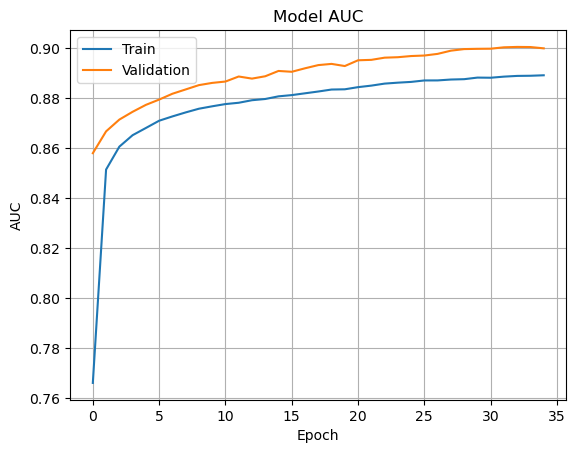

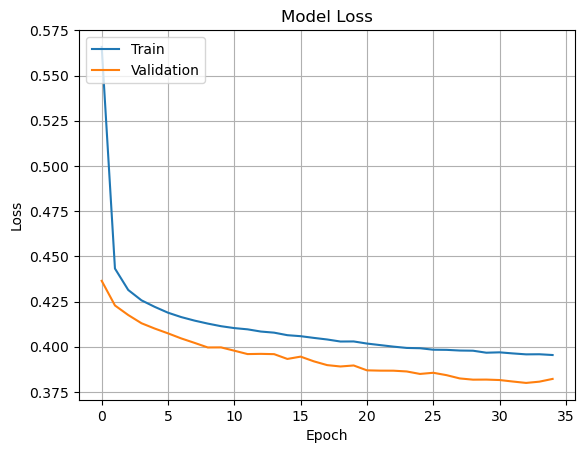

In [33]:

# Create a pandas DataFrame from the history object
history_df = pd.DataFrame(history.history)

# Plot the training & validation AUC scores
history_df[['AUC', 'val_AUC']].plot()
plt.title("Model AUC")
plt.ylabel("AUC")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Plot the training & validation loss scores
history_df[['loss', 'val_loss']].plot()
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [34]:
print("Saving all artifacts...")

# --- Save the trained TensorFlow/Keras model ---
model.save('reranker_model.keras')
print("  - Saved reranker_model.keras")

# --- Save the scaler ---
joblib.dump(scaler, 'standard_scaler.pkl')
print("  - Saved standard_scaler.pkl")

# --- Save the feature tables ---
user_features.to_parquet('user_features.parquet')
print("  - Saved user_features.parquet")

item_features.to_parquet('item_features.parquet')
print("  - Saved item_features.parquet")

# --- Save the label encoders ---
joblib.dump(encoders, 'label_encoders.pkl')
print("  - Saved label_encoders.pkl")

print("\nAll artifacts are saved and ready for the prediction service.")

Saving all artifacts...
  - Saved reranker_model.keras
  - Saved standard_scaler.pkl


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.